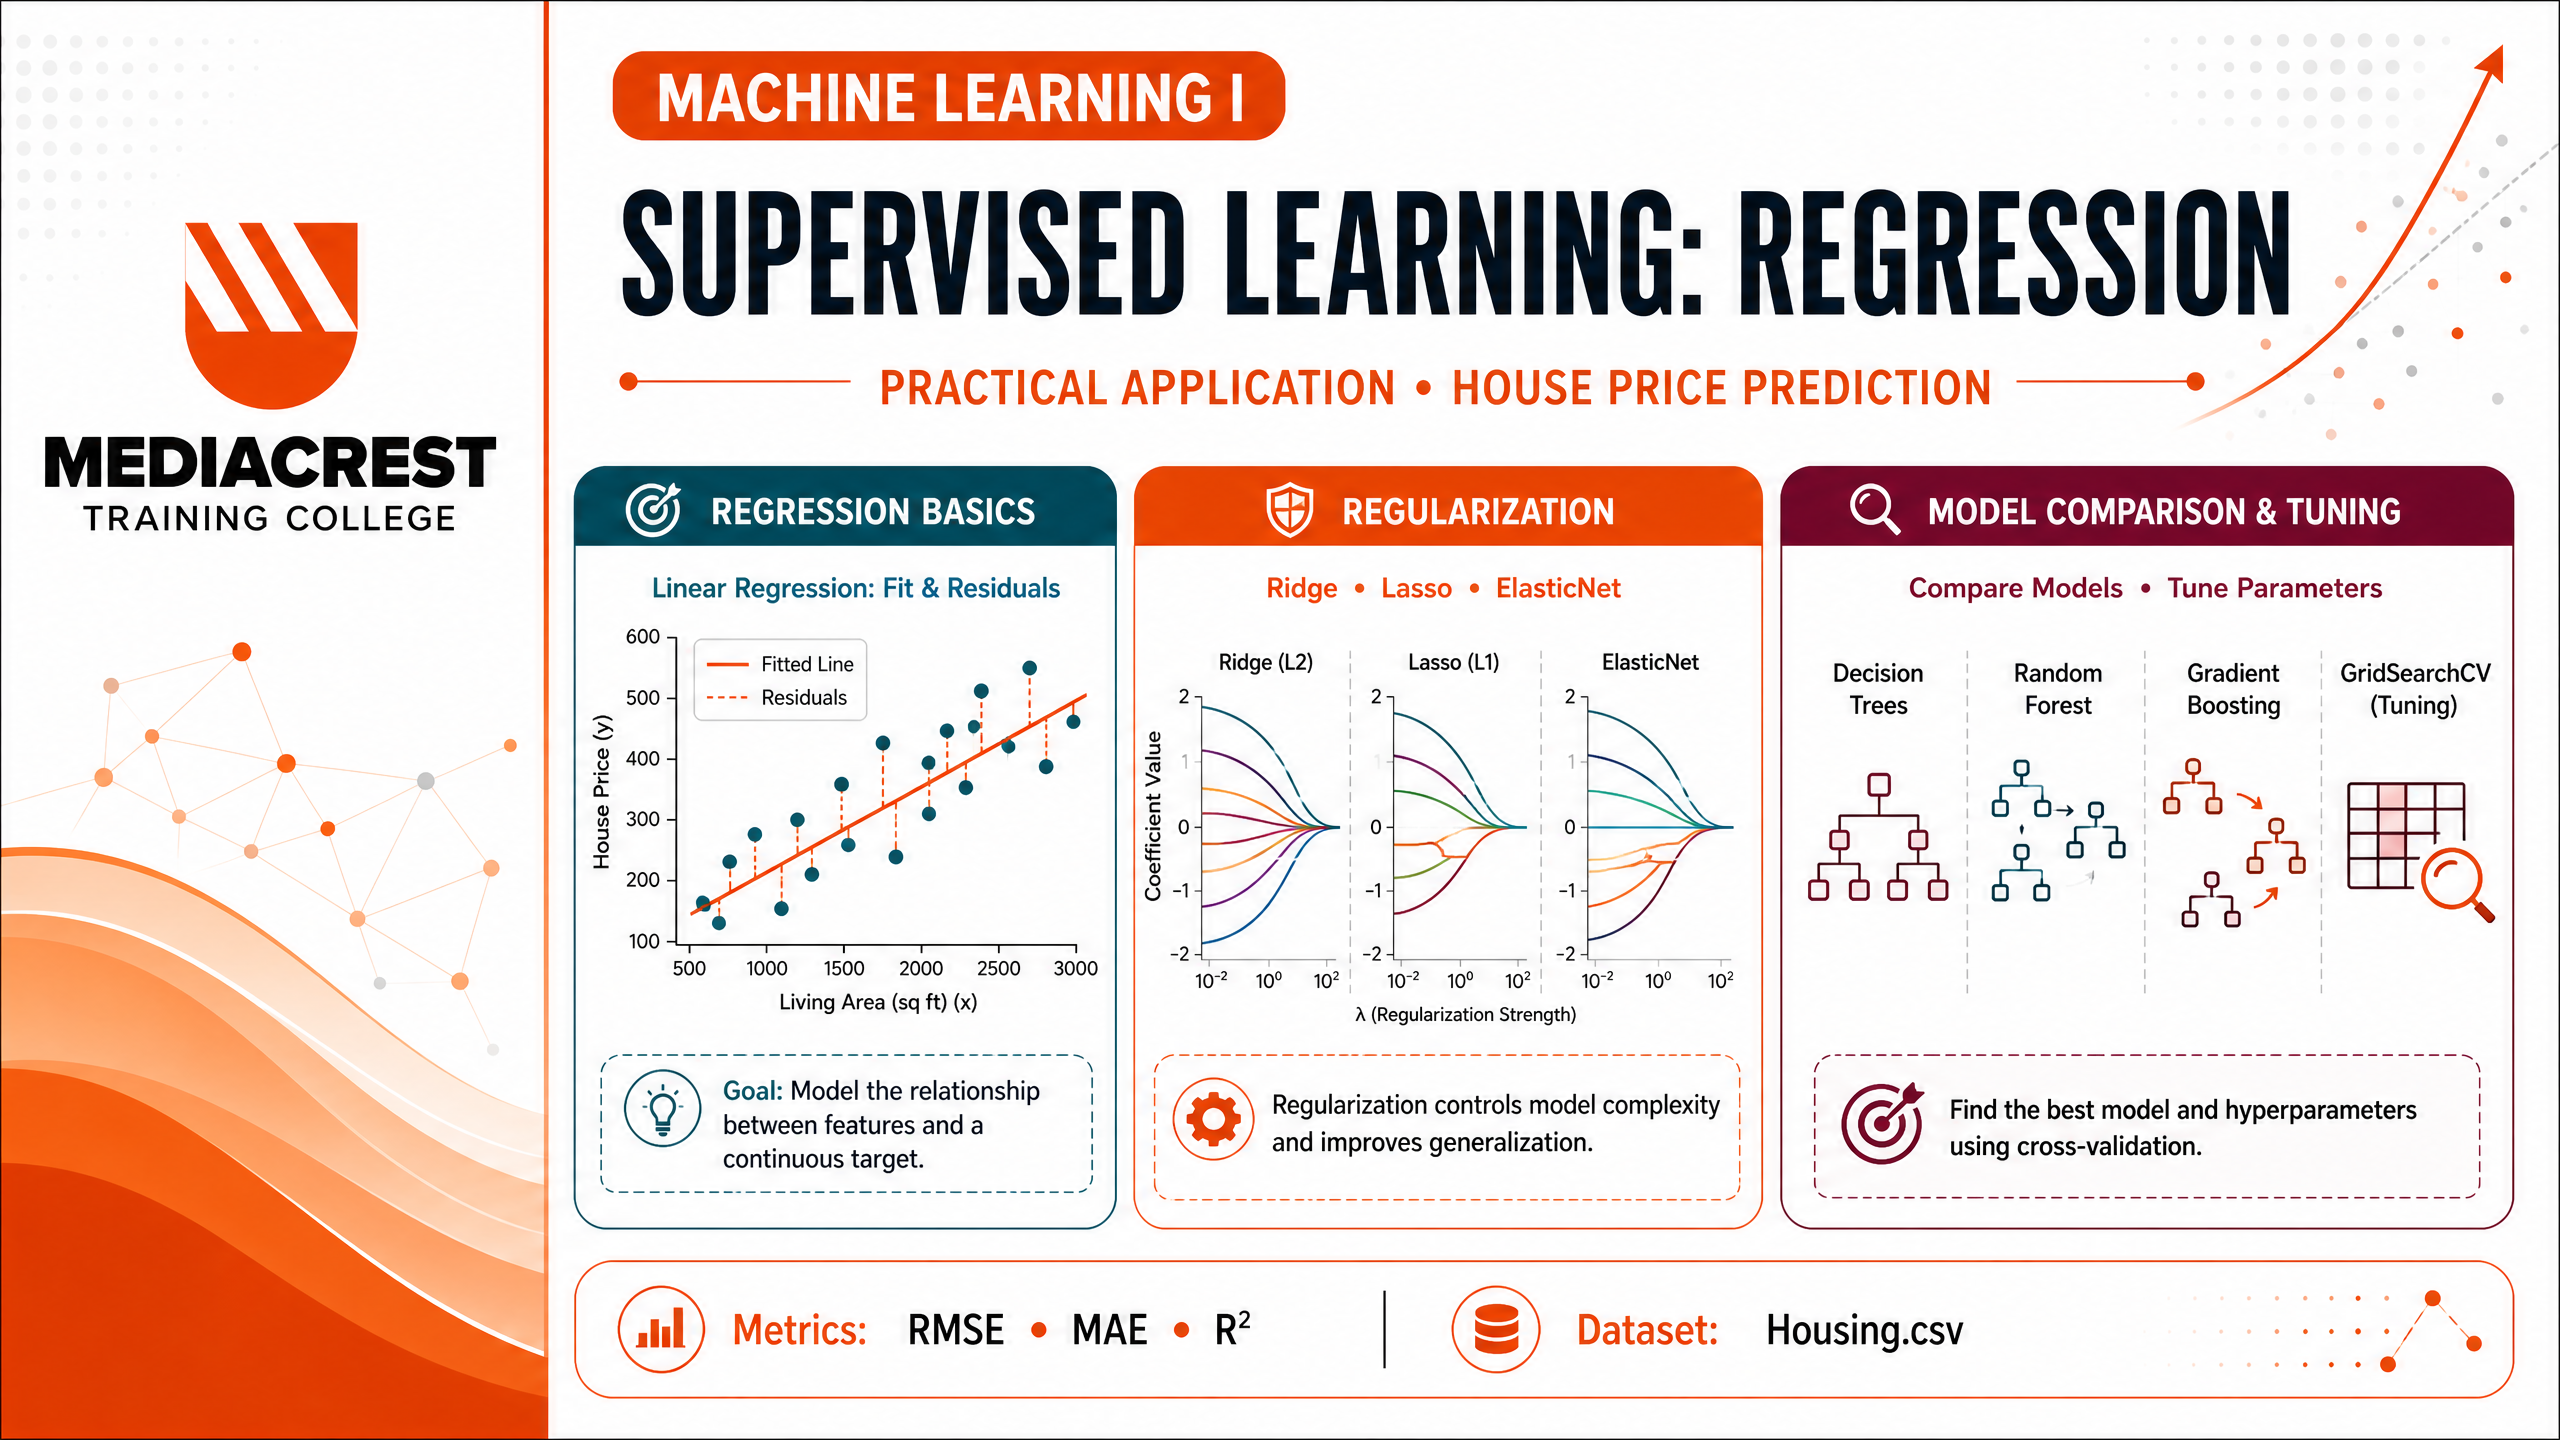

## **MACHINE LEARNING I: SUPERVISED LEARNING (REGRESSION FOCUS)**
### **Advanced Data Analytic and Machine Learning**

> **House Price Prediction Problem**

### **OBJECTIVES**
1. Design a Robust Machine Learning Pipeline
2. Control Model Complexity and Overfitting
3. Compare Tree-Based Models (Decision Tree, RF, XGboost)
4. Perform Hyperparameter Tuning (GridSearchCV)
5. Evaluate and Select the Best Model (RMSE, MAE, MAPE, $R^2$)

### **Load the Required Libraries**

#### **User-Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Scikit-Learn Core Modules***

In [2]:
from sklearn.model_selection import (train_test_split, 
                                     cross_val_score, 
                                     KFold, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer   
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             mean_absolute_percentage_error, 
                             r2_score)

#### **Regression Algorithms**

In [3]:
from sklearn.linear_model import (LinearRegression, 
                                  Ridge, Lasso, 
                                  ElasticNet)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor)

#### **Suppress Warnings for Cleaner Outputs**

In [4]:
import warnings
warnings.filterwarnings('ignore')

#### **Set up the Professional Theme for Visualization**

In [6]:
sns.set_theme(style='darkgrid',
              context = 'notebook',
              palette = 'mako',
              font_scale = 1.2)

plt.rcParamsDefault.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120})

### **PART 1: LOAD AND EXPLORE THE DATA**

In [7]:
df = pd.read_csv('Housing.csv')

In [8]:
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 10 Rows:")
df.head(10)

Dataset Shape: (545, 13)

First 10 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


#### **Explore and Check the Presence of Missing Values**

In [9]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


#### **Check the Distribution of the Target Variable**

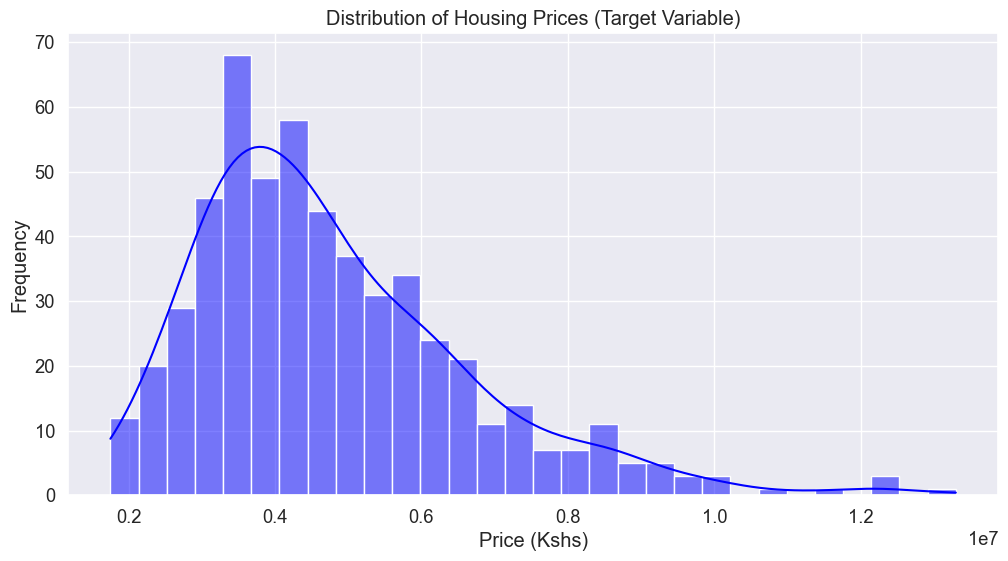

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='price', 
             bins=30, 
             kde=True,
             color='blue')

plt.title('Distribution of Housing Prices (Target Variable)')
plt.xlabel('Price (Kshs)')
plt.ylabel('Frequency')
plt.show()

### **PART 2: FEATURES SELECTION AND ENGINEERING FOR ML PIPELINE**

#### **Separate Features from the Target**

In [14]:
X = df.drop('price', axis=1)
y = df['price']

In [15]:
X.head(10)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [16]:
y.head(10)

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
5    10850000
6    10150000
7    10150000
8     9870000
9     9800000
Name: price, dtype: int64

#### **Identification of the Variables**

In [17]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              545 non-null    int64 
 1   bedrooms          545 non-null    int64 
 2   bathrooms         545 non-null    int64 
 3   stories           545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
dtypes: int64(5), object(7)
memory usage: 51.2+ KB


#### **Select the Numeric and Categorical Variables**

In [18]:
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                        'airconditioning', 'prefarea', 'furnishingstatus']

#### **Create the Pre-Processor**

> 1. Numeric Transformer (Crucial for Ridge, Lasso and Elastic Net Regression Model)

This approaches converts the numeric variables to have a mean of zero (0) and a variance of one (1)

In [22]:
numeric_transformer = StandardScaler()

> 2. Categorical Transformer (One-Hot-Encoding)

> **Frequency Table for Furnish Status**

In [19]:
X['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [20]:
categorical_transformer = OneHotEncoder(drop='first', 
                                        handle_unknown='ignore')

#### **Combine the Preprocessor**

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### **PART 3: TRAIN TEST-SPLIT**

At this point, we  split the data into 80% training set size and 20% testing set size

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Training Set Shape: {X_train.shape[0]} rows)")
print(f"Testing Set Shape: {X_test.shape[0]} rows)")

Training Set Shape: 436 rows)
Testing Set Shape: 109 rows)


### **STEP 4: MODEL DEFINITION AND CROSS VALIDATION STRATEGY**

* Define the dictionary of models to compare
* Wrap the models in a pipeline to ensure scaling is applied ONLY to the training fold during the CV, preventing data leakage. 

In [25]:
models = {
    "Ridge Regression": Pipeline([('preprocessor', preprocessor),
                                  ('model', Ridge(random_state=42))]),
    "Lasso Regression": Pipeline([('preprocessor', preprocessor),
                                  ('model', Lasso(random_state=42))]),
    "Elastic Net": Pipeline([('preprocessor', preprocessor),
                             ('model', ElasticNet(random_state=42))]),
    "Decision Tree": Pipeline([('preprocessor', preprocessor),
                               ('model', DecisionTreeRegressor(random_state=42))]),
    "Random Forest": Pipeline([('preprocessor', preprocessor),
                               ('model', RandomForestRegressor(random_state=42))]),
    "Gradient Boosting": Pipeline([('preprocessor', preprocessor),
                                   ('model', GradientBoostingRegressor(random_state=42))])
}

#### **CUSTOM SCORING FUNCTION FOR CROSS VALIDATION**

In [26]:
def get_cv_scores(model, X, y, cv = 5):
    rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error'))
    mae_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    mape_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_percentage_error')
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    
    return {
        'RMSE (Mean)': rmse_scores.mean(),
        'RMSE (std)': rmse_scores.std(),
        'MAE (Mean)': mae_scores.mean(),
        'MAPE (Mean)': mape_scores.mean(),
        'R2 (Mean)': r2_scores.mean()
    }

In [30]:
cv_results = {}
for name, model in models.items():
    scores = get_cv_scores(model, X_train, y_train, cv=5)
    cv_results[name] = scores
    print(f"{name:20} |CV RMSE: {scores['RMSE (Mean)']:.4f} | CV MAE: {scores['MAE (Mean)']:.4f} | CV MAPE: {scores['MAPE (Mean)']:.4f} | CV R2: {scores['R2 (Mean)']:.4f}")

Ridge Regression     |CV RMSE: 1008.0815 | CV MAE: 747102.0961 | CV MAPE: 0.1646 | CV R2: 0.6476
Lasso Regression     |CV RMSE: 1008.4501 | CV MAE: 748437.8438 | CV MAPE: 0.1649 | CV R2: 0.6470
Elastic Net          |CV RMSE: 1048.1392 | CV MAE: 805871.2117 | CV MAPE: 0.1827 | CV R2: 0.5902
Decision Tree        |CV RMSE: 1266.7003 | CV MAE: 1106677.1604 | CV MAPE: 0.2423 | CV R2: 0.1167
Random Forest        |CV RMSE: 1044.0870 | CV MAE: 766938.4118 | CV MAPE: 0.1699 | CV R2: 0.5969
Gradient Boosting    |CV RMSE: 1050.8980 | CV MAE: 790067.0778 | CV MAPE: 0.1739 | CV R2: 0.5857


#### **Cross-Validation Model Comparison**

The models were evaluated using **5-fold cross-validation** based on RMSE, MAE, MAPE, and $R^2$. The results are summarized below.

#### **Best Model: Ridge Regression**

**Ridge Regression is the best-performing model overall.** It achieves the:

* **Lowest RMSE:** 1008.08
* **Lowest MAE:** 747,102.10
* **Lowest MAPE:** 16.46%
* **Highest $R^2$:** 0.6476

The $R^2$ of **0.6476** indicates that Ridge Regression explains approximately **64.76% of the variation in the dependent variable** on cross-validation data. Its MAPE of **16.46%** indicates that predictions deviate from the actual values by approximately 16.5% on average, expressed as a percentage.

The results also show that **Lasso Regression performs almost identically** to Ridge, with $R^2=0.6470$ and MAPE = 16.49%. However, Ridge has marginally better performance on all four evaluation metrics.

### Interpretation of the Other Models

**Elastic Net** performed moderately well $R^2=0.5902$, but was inferior to both Ridge and Lasso. Its higher RMSE, MAE, and MAPE indicate less accurate predictions.

**Random Forest** performed better than Elastic Net and Gradient Boosting but still substantially below Ridge $R^2=0.5969$. This suggests that the underlying relationships in the data may be adequately captured by a regularized linear model without requiring a highly flexible tree-based approach.

**Gradient Boosting** achieved $R^2=0.5857$, while its RMSE and MAE were also higher than those of Ridge.

**Decision Tree** was clearly the weakest model, with an $R^2$ of only **0.1167** and the highest errors. This indicates that a single decision tree does not capture the underlying structure of the outcome effectively.

#### **Overall Conclusion**

> **Ridge Regression should be selected as the final model because it provides the best predictive performance across all four cross-validation metrics.** It has the lowest prediction errors (RMSE, MAE and MAPE) and the highest explanatory power $R^2$. Although Lasso performs very similarly, Ridge has a small but consistent advantage across every metric, making it the preferred model for prediction.

**One caution:** Your MAE values are around **747,102**, while RMSE is only about **1,008**. Those scales are inconsistent if both metrics were calculated on the same untransformed target. I would verify the metric calculation—particularly whether the target was log-transformed or whether MAE was accidentally calculated after reversing a transformation—before putting these results into a final thesis/report.

Available next action: Create a downloadable PDF file here in this chat containing the findings and recommendations above


### **STEP 5: HYPERPARAMETER TUNING (GridSearchCV)**

> Let us assume that Ridge regression and Random Forest are the Two Best Models

In [31]:
## 1. Ridge Regression Hyperparameter Tuning
ridge_param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

## 2. Random Forest Hyperparameter Tuning
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10]
}

#### **PASS THE GRIDSEARCH TO THE MODELS TRAINED**

In [32]:
### Ridge Regression Hyperparameter Tuning

print("Ridge Regression Hyperparameter Tuning")
ridge_grid = GridSearchCV(models['Ridge Regression'],
                          ridge_param_grid,
                          cv=5,
                          scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Regression Parameters: {ridge_grid.best_params_['model__alpha']}")


### Random Forest Hyperparameter Tuning
print("Random Forest Hyperparameter Tuning")
rf_grid = GridSearchCV(models['Random Forest'],
                       rf_param_grid,
                       cv=5,
                       scoring='neg_mean_squared_error')
rf_grid.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {rf_grid.best_params_}")

Ridge Regression Hyperparameter Tuning
Best Ridge Regression Parameters: 10
Random Forest Hyperparameter Tuning
Best Random Forest Parameters: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 100}


#### **UPDATE THE MODEL DICTIONARY WITH THE BEST ESTIMATORS**

In [33]:
tuned_models = {
    "Tuned Ridge":ridge_grid.best_estimator_,
    "Tuned Random Forest":rf_grid.best_estimator_,
    "Gradient Boosting (Baseline)":models['Gradient Boosting']
}

#### **STEP 6: FINAL MODEL EVALUATION ON HOLD OUT TESTING SET**

In [34]:
evaluation_results = {}
for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    }
    
    print(f"{name:20} |Test RMSE: {rmse:.4f} | Test MAE: {mae:.4f} | Test MAPE: {mape:.4f} | Test R2: {r2:.4f}")

Tuned Ridge          |Test RMSE: 1338647.4717 | Test MAE: 979663.5037 | Test MAPE: 0.2136 | Test R2: 0.6455
Tuned Random Forest  |Test RMSE: 1444212.6715 | Test MAE: 1048902.2441 | Test MAPE: 0.2242 | Test R2: 0.5874
Gradient Boosting (Baseline) |Test RMSE: 1299385.9799 | Test MAE: 959748.9636 | Test MAPE: 0.2072 | Test R2: 0.6660


### **Tuned Model Results After Grid Search**

Following the initial cross-validation comparison, the leading models were further optimized using **GridSearchCV** to identify the best hyperparameter combinations. The tuned models were then evaluated on the **independent test set**.

### **Test-Set Performance After Hyperparameter Tuning**

| Model                            |        Test RMSE |       Test MAE |  Test MAPE | Test \(R^2\) |
| -------------------------------- | ---------------: | -------------: | ---------: | -----------: |
| **Tuned Ridge**                  |     1,338,647.47 |     979,663.50 |     21.36% |       0.6455 |
| **Tuned Random Forest**          |     1,444,212.67 |   1,048,902.24 |     22.42% |       0.5874 |
| **Gradient Boosting (Baseline)** | **1,299,385.98** | **959,748.96** | **20.72%** |   **0.6660** |

### **Best Final Model: Gradient Boosting**

Based on the **independent test-set evaluation, Gradient Boosting is the best-performing model**.

It achieved:

* **Lowest Test RMSE:** 1,299,385.98
* **Lowest Test MAE:** 959,748.96
* **Lowest Test MAPE:** 20.72%
* **Highest Test \(R^2\):** 0.6660

Thus, although **Ridge Regression was the best model during cross-validation**, the final test-set results show that **Gradient Boosting generalizes better to unseen data**.

### **Comparison with the Cross-Validation Results**

An important finding emerges when the initial CV results are compared with the final test results:

| Model             | CV \(R^2\) | Test \(R^2\) |  Test MAPE |
| ----------------- | ---------: | -----------: | ---------: |
| Ridge             | **0.6476** |       0.6455 |     21.36% |
| Random Forest     |     0.5969 |       0.5874 |     22.42% |
| Gradient Boosting |     0.5857 |   **0.6660** | **20.72%** |

The initial cross-validation suggested that **Ridge Regression** was the strongest model, with an \(R^2\) of 0.6476. However, after model tuning and evaluation on completely unseen test observations, **Gradient Boosting achieved a substantially higher \(R^2\) of 0.6660**.

This represents an improvement of approximately **2.84 percentage points** over the tuned Ridge model:

$$
0.6660 - 0.6455 = 0.0205
$$

or approximately **3.18% relative improvement in \(R^2\)** compared with Ridge.

Gradient Boosting also reduced the test RMSE and MAE relative to Ridge, indicating more accurate predictions.

### **Interpretation**

The results suggest that the relationship between the predictors and the outcome may contain **non-linear patterns and interactions** that a linear regularized model such as Ridge cannot fully capture. Gradient Boosting is capable of modelling such complex relationships by sequentially combining decision trees.

Interestingly, the **baseline Gradient Boosting model outperformed the tuned Ridge and tuned Random Forest models** on the independent test set. Therefore, hyperparameter tuning does not automatically guarantee superior predictive performance; the final model should be selected based on **unseen test-set performance**, provided the test set has been kept completely separate throughout model development and tuning.

### **Final Model Selection**

> **Gradient Boosting is selected as the final predictive model.** Although Ridge Regression demonstrated the strongest performance during cross-validation, the independent test-set evaluation showed that Gradient Boosting provided superior generalization, achieving the highest $R^2$ (0.6660), lowest RMSE (1,299,385.98), lowest MAE (959,748.96), and lowest MAPE (20.72%). Therefore, Gradient Boosting offers the best overall predictive accuracy for the final model on the external data that the models have not seen.

### **Recommended Reporting Statement**

You can use the following directly in your results section:

### **Model Tuning and Final Model Selection**

Following the initial model comparison, GridSearchCV was employed to optimize the hyperparameters of the leading Ridge Regression and Random Forest models. The tuned models were subsequently evaluated using an independent test dataset, while the baseline Gradient Boosting model was included for comparison. The results indicated that Tuned Ridge Regression achieved a test RMSE of 1,338,647.47, MAE of 979,663.50, MAPE of 21.36%, and \(R^2\) of 0.6455. Tuned Random Forest performed less favourably, with a test RMSE of 1,444,212.67, MAE of 1,048,902.24, MAPE of 22.42%, and \(R^2\) of 0.5874.

In contrast, the Gradient Boosting model achieved the best overall test-set performance, with an RMSE of 1,299,385.98, MAE of 959,748.96, MAPE of 20.72%, and \(R^2\) of 0.6660. Therefore, Gradient Boosting was selected as the final predictive model. Although Ridge Regression had demonstrated the strongest performance during cross-validation (\(R^2=0.6476\)), Gradient Boosting demonstrated superior generalization to previously unseen observations. Its higher \(R^2\) indicates that it explained approximately 66.6% of the variation in the outcome, while its lower RMSE, MAE, and MAPE indicate improved predictive accuracy compared with the tuned Ridge and Random Forest models.

The superiority of Gradient Boosting suggests that the underlying relationships between the predictors and the outcome may include non-linear effects and interactions that are not fully captured by regularized linear models. The final model was therefore selected based on its performance on the independent test dataset, with Gradient Boosting providing the most favourable balance between predictive accuracy and explanatory performance.

**One important technical check:** the very large RMSE/MAE values relative to the MAPE suggest that the outcome is likely measured in large monetary/financial units, which may be perfectly reasonable. However, ensure that **RMSE and MAE are calculated on the same scale as the reported test predictions and actual values** before finalizing the thesis/report.
